# Entropy loss vs performance correlation

Focus: connect entropy dynamics with pass@k results to see whether lower entropy loss corresponds to better pass@k performance.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlepad"] = 12

# Robust data directory resolver (works from repo root or final_results/tools)

def get_data_dir() -> Path:
    cwd = Path.cwd().resolve()
    candidates = []
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data")
        candidates.append(parent / "data")
    for c in candidates:
        if c.exists():
            return c
    raise FileNotFoundError(f"Could not locate data directory in candidates: {candidates}")

DATA_DIR = get_data_dir()


DATA_DIR = get_data_dir()

combined = pd.read_csv(DATA_DIR / 'combined_wide.csv')
combined = combined.drop(columns=[c for c in ['Unnamed: 0'] if c in combined.columns])
combined['seed'] = combined['seed'].astype(str)
metrics = [c for c in combined.columns if c.startswith('pass@') or c == 'avg@32']
passk_metrics = [m for m in metrics if m.startswith('pass@')]

ent = pd.read_csv(DATA_DIR / 'entropyloss_wide.csv')
ent['seed'] = ent['seed'].astype(str)


DATA_DIR_CANDIDATES = [
    Path.cwd() / "final_results" / "data",
    Path.cwd().parent / "final_results" / "data",
    Path.cwd() / "data",
    Path.cwd().parents[1] / "final_results" / "data",
    Path(__file__).resolve().parents[1] / "data" if '__file__' in globals() else Path.cwd() / "final_results" / "data",
]

# Robust data path resolver (works when running from repo root or final_results/tools)

# Robust data path resolver (works when running from repo root or final_results/tools)

def resolve_data_path(filename: str) -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "final_results" / "data" / filename,
        cwd / "data" / filename,
    ]
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data" / filename)
        candidates.append(parent / "data" / filename)
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename} in candidates: {candidates}")




In [2]:

# Align steps between entropy and performance
steps = sorted(combined['Step'].unique())
perf = combined.groupby(['Step', 'algorithm'], as_index=False)[metrics].mean()

ent_mean = ent.groupby(['Step', 'algorithm'], as_index=False)['actor/entropy_loss'].mean()
ent_mean = ent_mean[ent_mean['Step'].isin(steps)]

merged = perf.merge(ent_mean, on=['Step', 'algorithm'], how='left')
final_step = int(perf['Step'].max())
final_df = merged[merged['Step'] == final_step].copy()


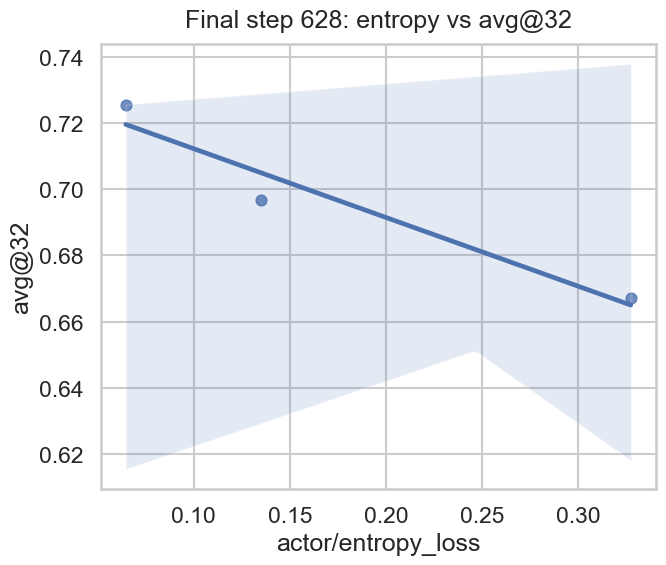

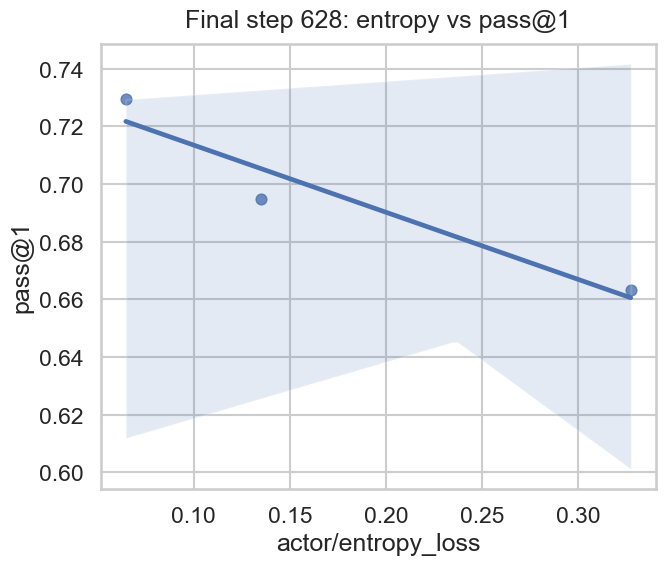

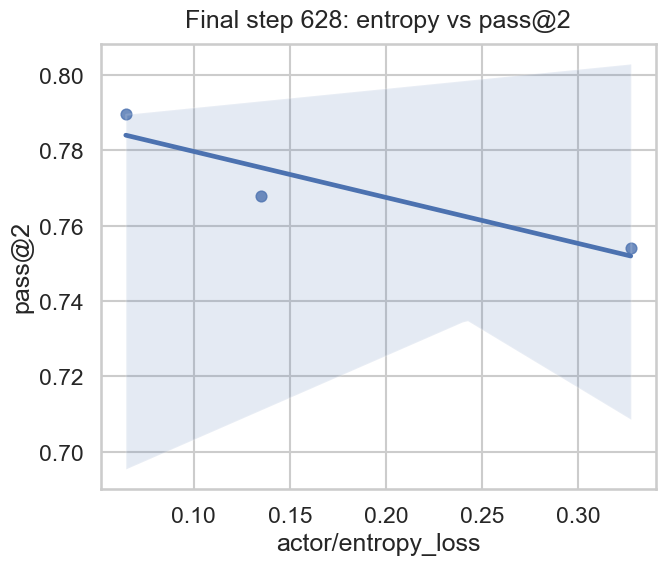

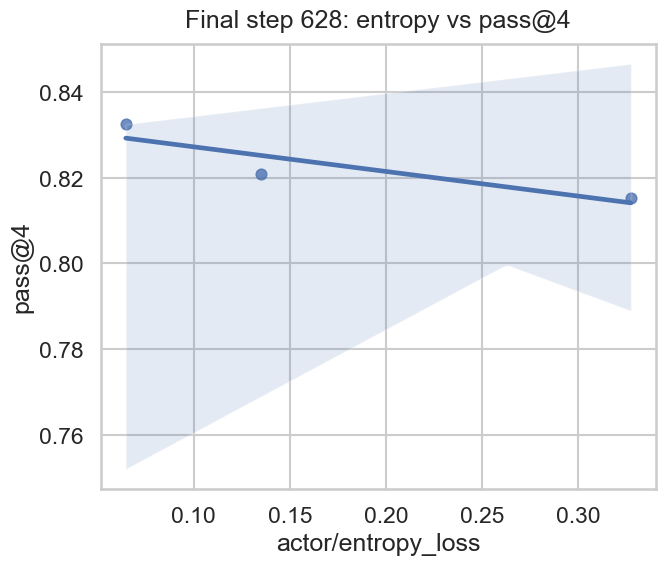

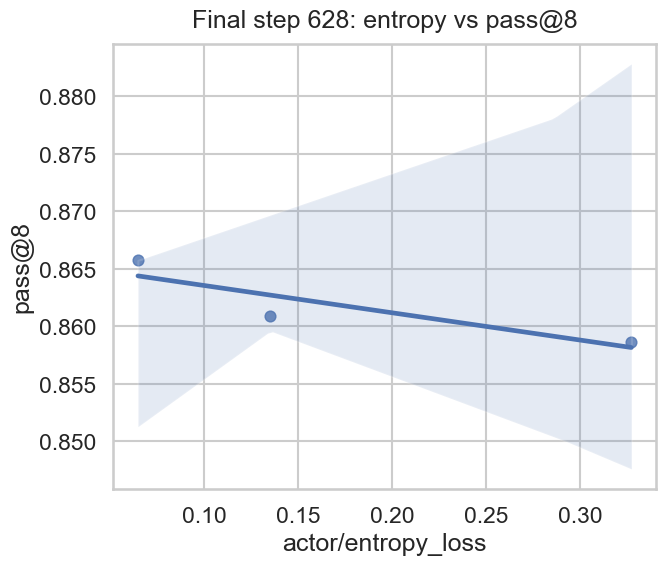

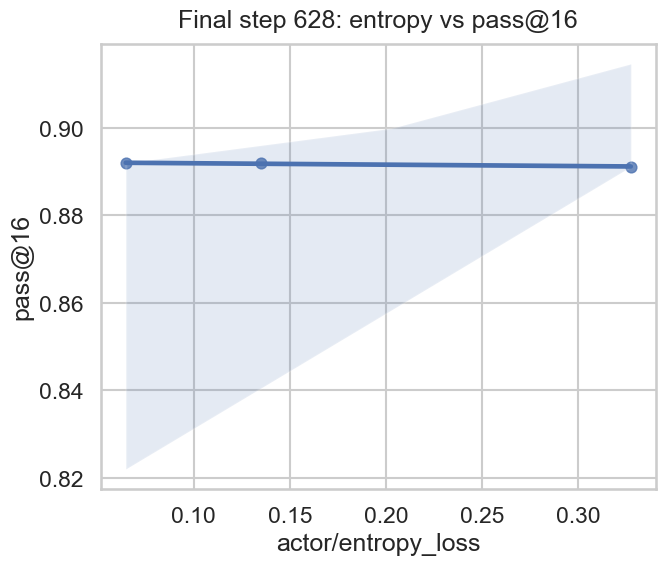

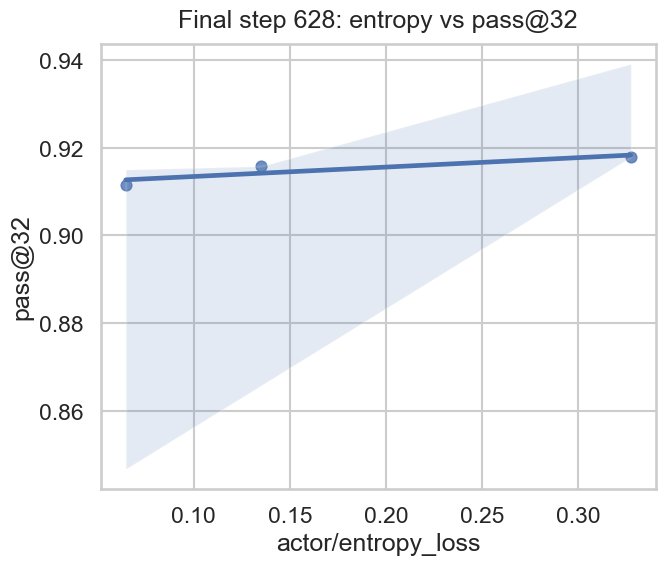

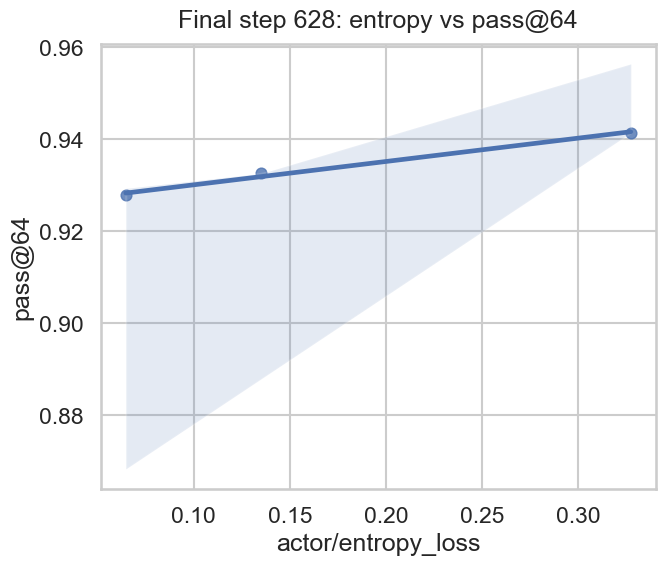

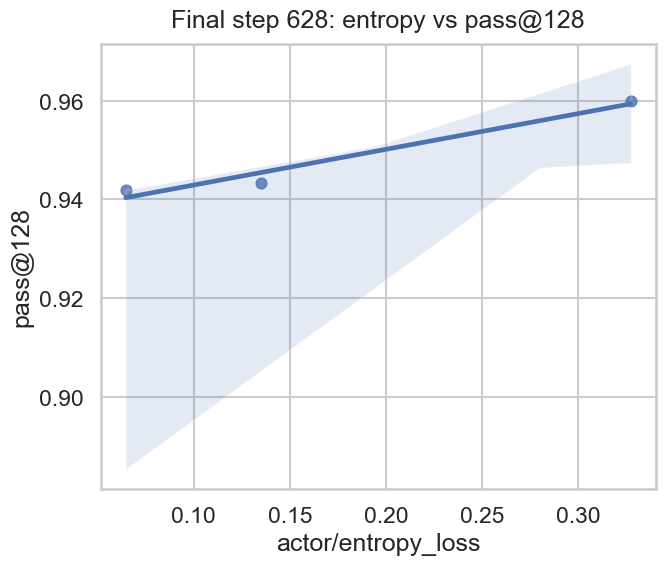

In [3]:

# Plot set A: final-step entropy vs performance
for metric in metrics:
    plt.figure(figsize=(7, 6))
    sns.regplot(data=final_df, x='actor/entropy_loss', y=metric, scatter_kws={'s': 60, 'alpha': 0.8})
    plt.title(f'Final step {final_step}: entropy vs {metric}')
    plt.xlabel('actor/entropy_loss')
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()
    plt.close()


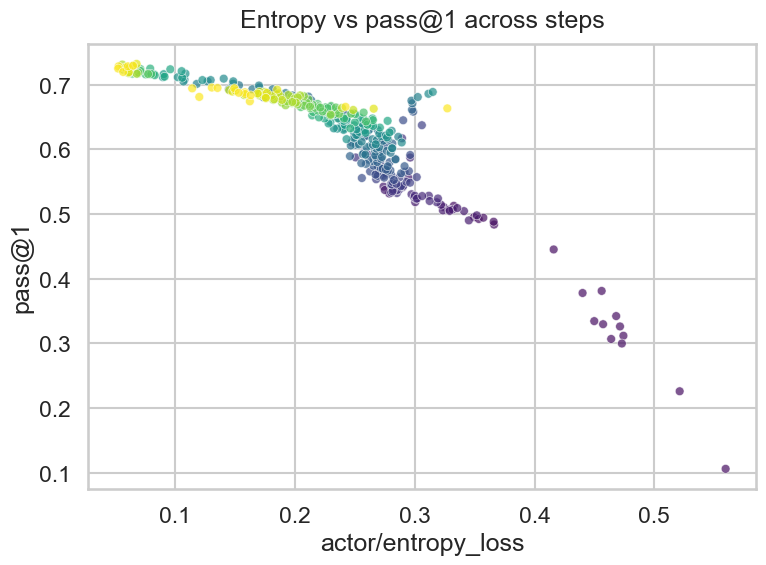

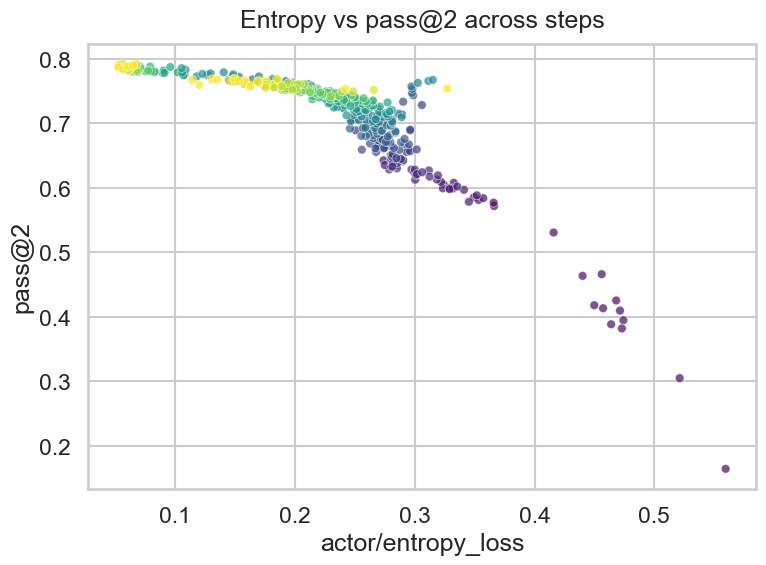

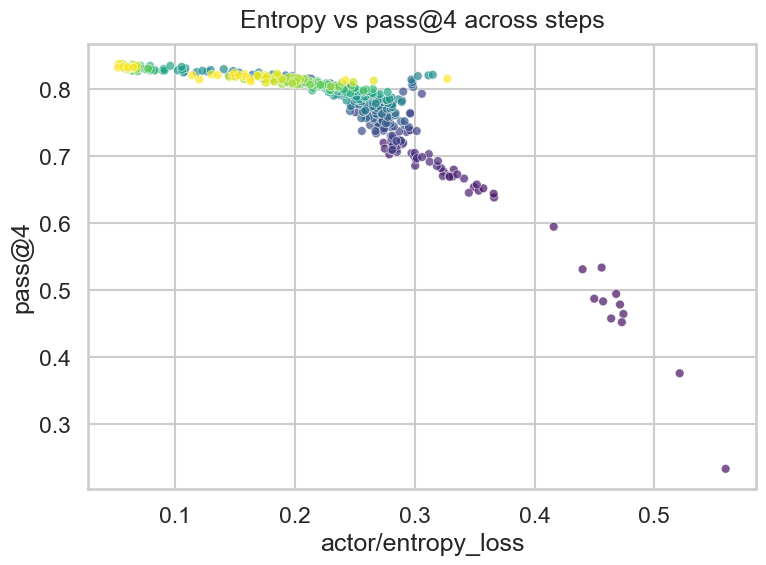

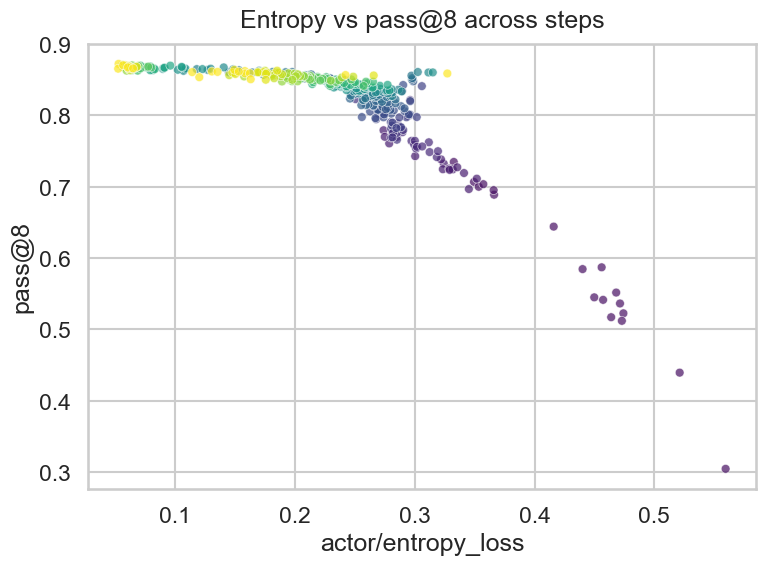

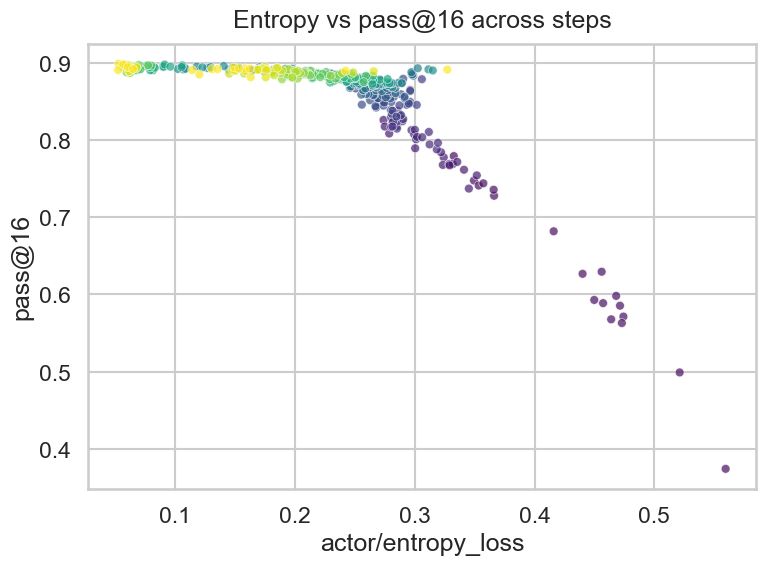

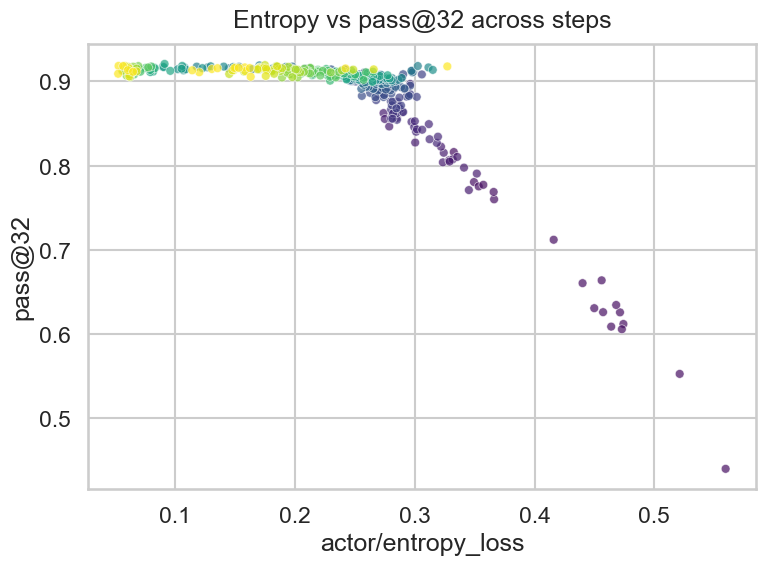

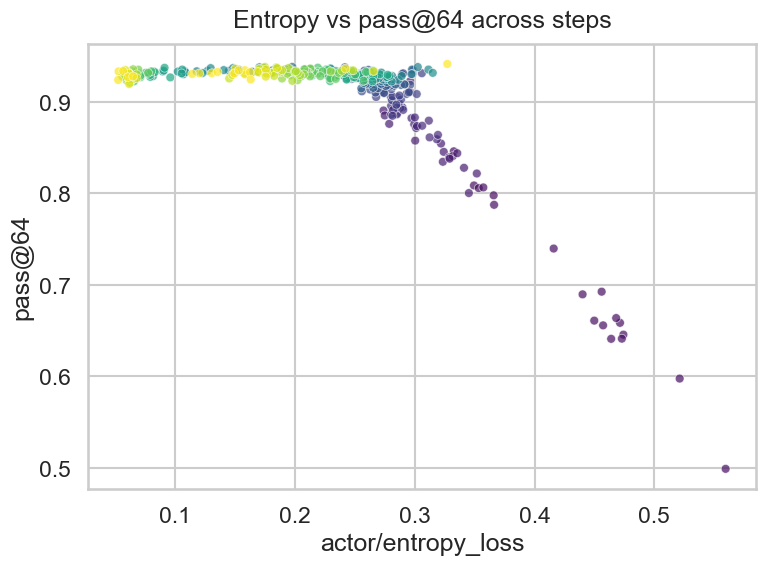

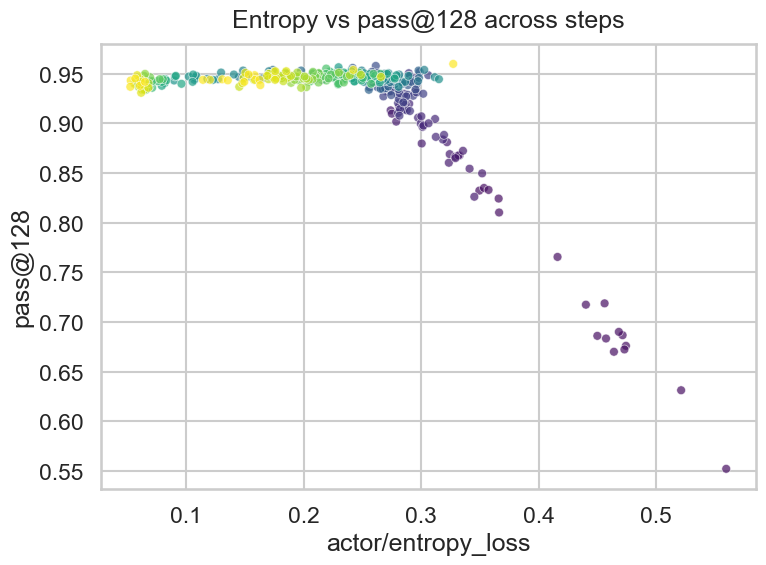

In [4]:

# Plot set B: entropy vs performance across steps
for metric in passk_metrics:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=merged, x='actor/entropy_loss', y=metric, hue='Step', palette='viridis', s=40, alpha=0.7, legend=False)
    plt.title(f'Entropy vs {metric} across steps')
    plt.xlabel('actor/entropy_loss')
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()
    plt.close()


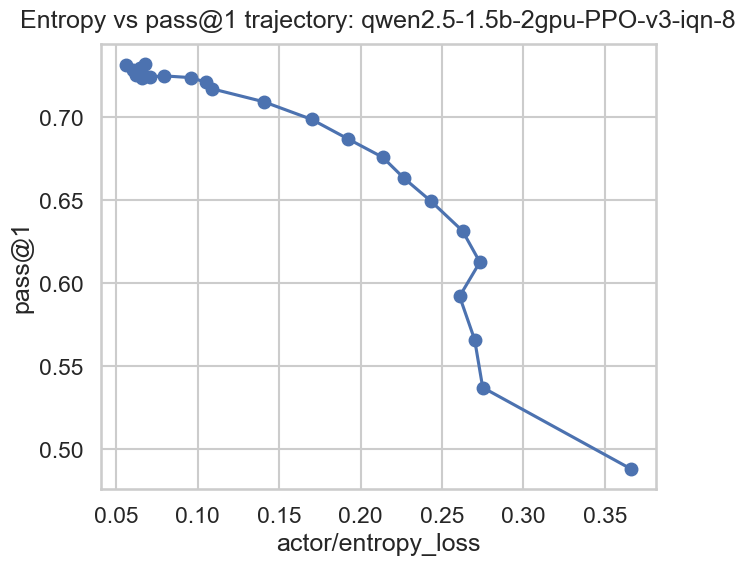

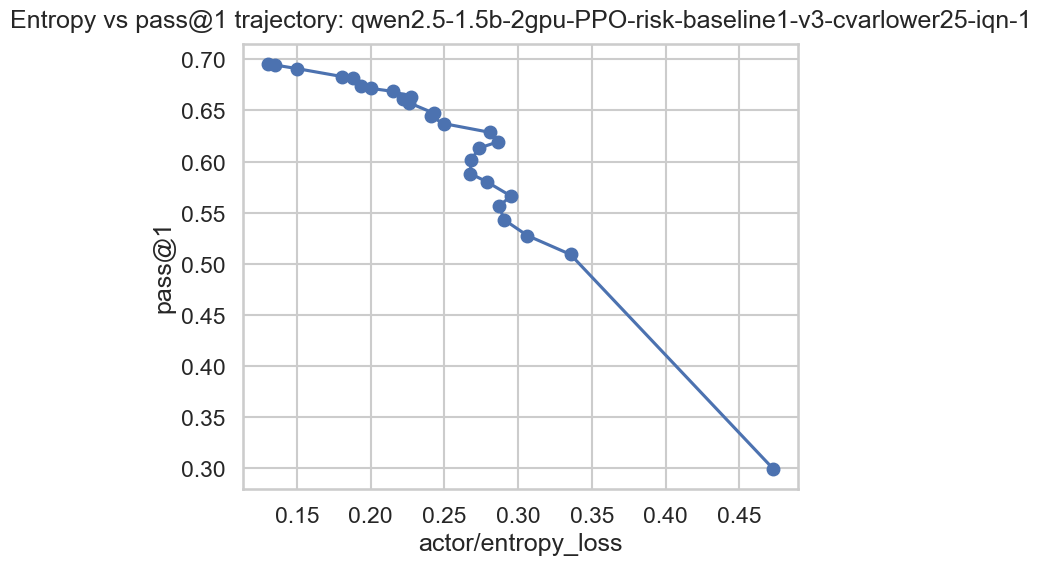

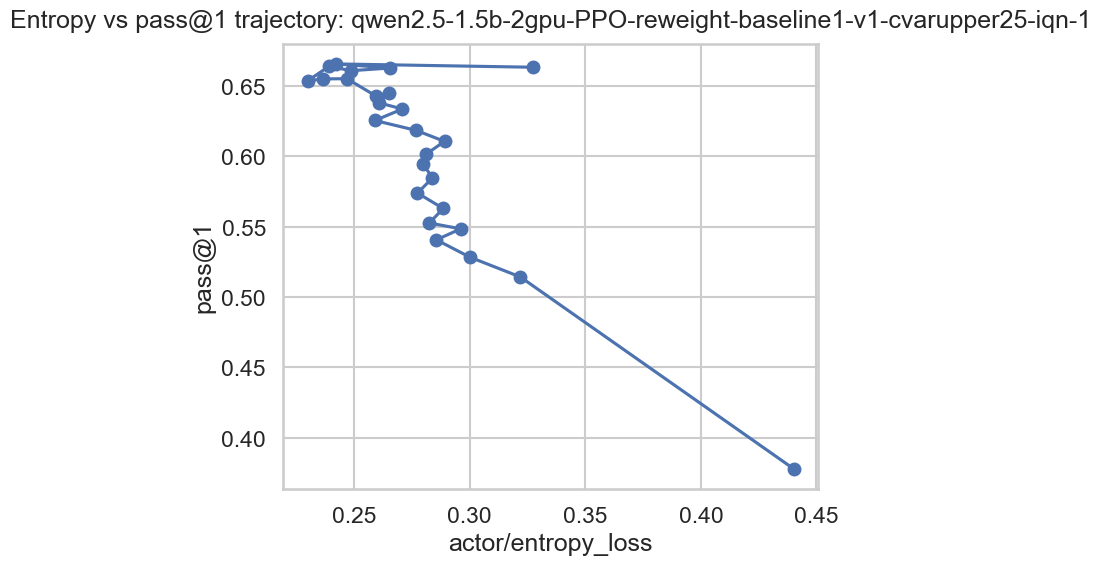

In [5]:

# Plot set C: algorithm-wise entropy vs pass@1 trajectory
algo_order = (
    final_df.sort_values('pass@1', ascending=False)['algorithm']
    .head(5)
    .tolist()
)
for algo in algo_order:
    sub = merged[merged['algorithm'] == algo].sort_values('Step')
    plt.figure(figsize=(7, 6))
    plt.plot(sub['actor/entropy_loss'], sub['pass@1'], marker='o')
    plt.title(f'Entropy vs pass@1 trajectory: {algo}')
    plt.xlabel('actor/entropy_loss')
    plt.ylabel('pass@1')
    plt.tight_layout()
    plt.show()
    plt.close()
